In [1]:
# EXPLANATION: Imports the necessary libraries for data manipulation and visualization.
# Input: None.
# Output: Loads numpy, pandas, matplotlib, and seaborn into the environment.
# Interpretation: Essential setup for executing the data processing and EDA steps ahead.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# EXPLANATION: Configures Pandas display settings to ensure all columns are visible.
# Input: None.
# Output: Modifies the global display options for Pandas.
# Interpretation: Helpful for inspecting wide datasets without truncation.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

In [3]:
# EXPLANATION: Reads the dataset into a Pandas DataFrame object.
# Input: 'Restaurant_revenue (1).csv' file from the directory.
# Output: A DataFrame variable named 'dataset'.
# Interpretation: Loads the raw restaurant data into memory for manipulation.
dataset = pd.read_csv('Restaurant_revenue.csv')

In [4]:
dataset.head()


,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,Japanese,36.236133,0,45,350.912040
1,24,40.020077,4.577892,Italian,17.952562,0,36,221.319091
2,81,41.981485,4.652911,Japanese,22.600420,1,91,326.529763
3,70,43.005307,4.416053,Italian,18.984098,1,59,348.190573
4,30,17.456199,3.475052,Italian,12.766143,1,30,185.009121


In [5]:
dataset.shape

(1000, 8)

In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number_of_Customers        1000 non-null   int64  
 1   Menu_Price                 1000 non-null   float64
 2   Marketing_Spend            1000 non-null   float64
 3   Cuisine_Type               1000 non-null   str    
 4   Average_Customer_Spending  1000 non-null   float64
 5   Promotions                 1000 non-null   int64  
 6   Reviews                    1000 non-null   int64  
 7   Monthly_Revenue            1000 non-null   float64
dtypes: float64(4), int64(3), str(1)
memory usage: 70.0 KB


In [7]:
# EXPLANATION: Selects and isolates only the continuous/numerical variables.
# Input: The 'dataset' DataFrame.
# Output: A list of column names with 'int64' or 'float64' datatypes.
# Interpretation: Identifies features like marketing spend and revenue that may require scaling.
dataset.select_dtypes(include=['int64', 'float64']).columns

Index(['Number_of_Customers', 'Menu_Price', 'Marketing_Spend',
       'Average_Customer_Spending', 'Promotions', 'Reviews',
       'Monthly_Revenue'],
      dtype='str')

In [8]:
# EXPLANATION: Checks if there are any missing values in the entire dataset.
# Input: The 'dataset' DataFrame.
# Output: A boolean value (True/False).
# Interpretation: A quick binary check to see if imputation is required.
dataset.isnull().values.any()

np.False_

In [9]:
# EXPLANATION: Calculates the total number of missing values across all cells.
# Input: The 'dataset' DataFrame.
# Output: Integer representing total null count.
# Interpretation: Gives the magnitude of missing data globally.
dataset.isnull().values.sum()

np.int64(0)

In [10]:
# EXPLANATION: Displays the count of missing values per individual column.
# Input: The 'dataset' DataFrame.
# Output: A series with column names and missing value counts.
# Interpretation: Pinpoints exactly which features have missing data.
dataset.isnull().sum()

Number_of_Customers          0
Menu_Price                   0
Marketing_Spend              0
Cuisine_Type                 0
Average_Customer_Spending    0
Promotions                   0
Reviews                      0
Monthly_Revenue              0
dtype: int64

In [11]:
# EXPLANATION: Checks if there are any completely duplicated rows.
# Input: The 'dataset' DataFrame.
# Output: A boolean value (True/False).
# Interpretation: Ensures data integrity by checking for exact duplicates.
dataset.duplicated().any()

np.False_

In [12]:
# EXPLANATION: Returns the exact count of duplicated rows.
# Input: The 'dataset' DataFrame.
# Output: Integer showing duplicate count.
# Interpretation: Quantifies the duplication issue if any exists.
dataset.duplicated().sum()

np.int64(0)

In [13]:
# EXPLANATION: Drops any duplicated rows to prevent model bias.
# Input: The 'dataset' DataFrame.
# Output: DataFrame is modified in-place.
# Interpretation: Cleans the dataset of repeated entries.
dataset.drop_duplicates(inplace=True)

In [14]:
# EXPLANATION: Checks the new dimensions after dropping rows.
# Input: Updated 'dataset'.
# Output: Tuple of (Rows, Columns).
# Interpretation: Confirms that the row count has been updated properly.
dataset.shape

(1000, 8)

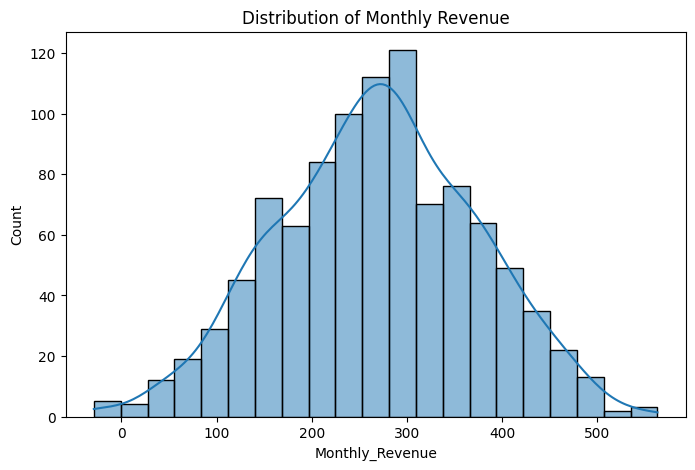

In [15]:
# EXPLANATION: Visualizes the distribution of the target variable 'Monthly_Revenue'.
# Input: 'Monthly_Revenue' column.
# Output: A histogram with a KDE curve.
# Interpretation: Shows if revenue values are normally distributed or skewed.
plt.figure(figsize=(8,5))
sns.histplot(dataset['Monthly_Revenue'], kde=True)
plt.title('Distribution of Monthly Revenue')
plt.show()

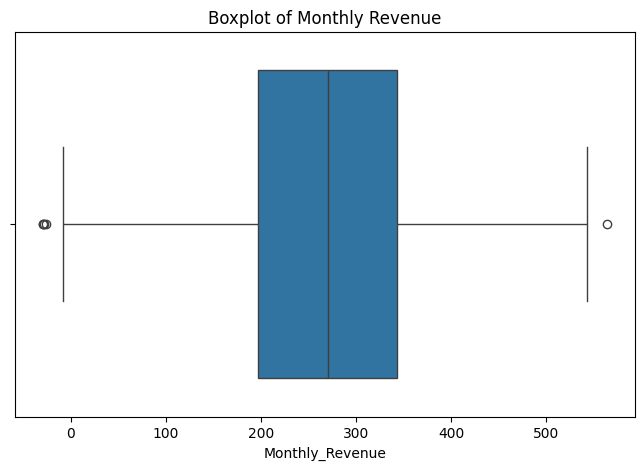

In [16]:
# EXPLANATION: Creates a boxplot for 'Monthly_Revenue'.
# Input: 'Monthly_Revenue' column.
# Output: Box-and-whisker plot.
# Interpretation: Visually identifies extremely high or low earning outlier restaurants.
plt.figure(figsize=(8,5))
sns.boxplot(x=dataset['Monthly_Revenue'])
plt.title('Boxplot of Monthly Revenue')
plt.show()

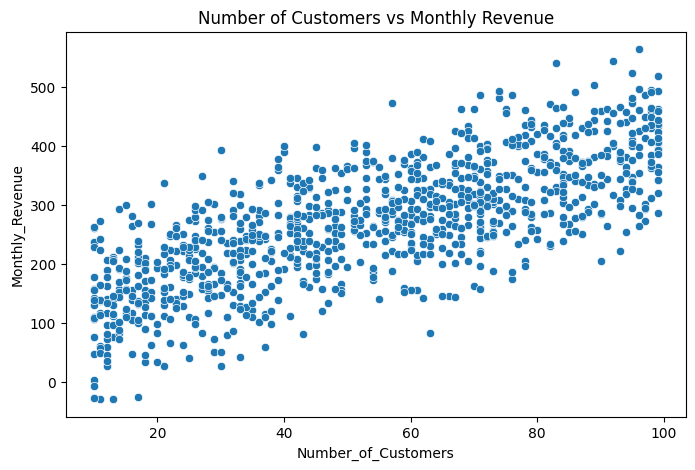

In [17]:
# EXPLANATION: Scatter plot for number of customers vs monthly revenue.
# Input: 'Number_of_Customers' and 'Monthly_Revenue'.
# Output: Scatter plot chart.
# Interpretation: Looks for a positive correlation trend between foot traffic and revenue.
plt.figure(figsize=(8,5))
sns.scatterplot(x='Number_of_Customers', y='Monthly_Revenue', data=dataset)
plt.title('Number of Customers vs Monthly Revenue')
plt.show()

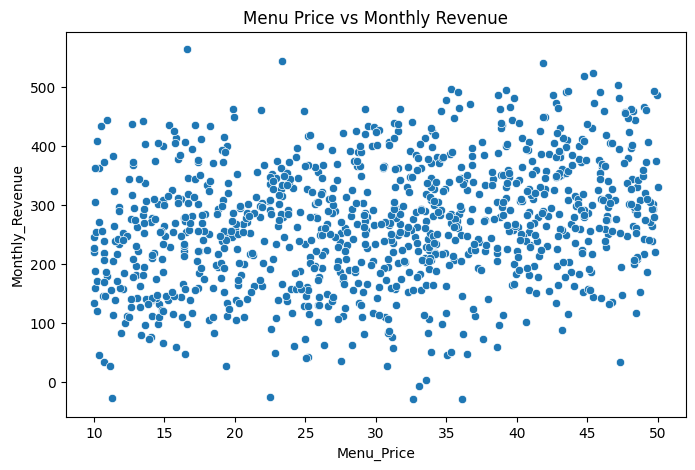

In [18]:
# EXPLANATION: Scatter plot for menu price vs monthly revenue.
# Input: 'Menu_Price' and 'Monthly_Revenue'.
# Output: Scatter plot chart.
# Interpretation: Observes if higher prices result in more or less total revenue.
plt.figure(figsize=(8,5))
sns.scatterplot(x='Menu_Price', y='Monthly_Revenue', data=dataset)
plt.title('Menu Price vs Monthly Revenue')
plt.show()

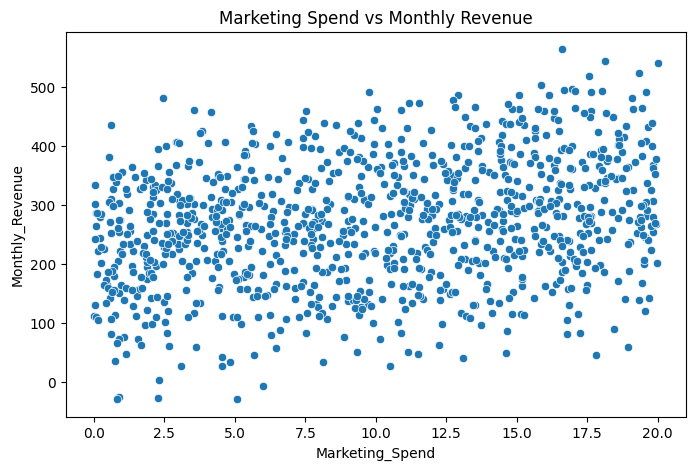

In [19]:
# EXPLANATION: Scatter plot for marketing spend vs monthly revenue.
# Input: 'Marketing_Spend' and 'Monthly_Revenue'.
# Output: Scatter plot chart.
# Interpretation: Checks if spending more on marketing directly increases revenue.
plt.figure(figsize=(8,5))
sns.scatterplot(x='Marketing_Spend', y='Monthly_Revenue', data=dataset)
plt.title('Marketing Spend vs Monthly Revenue')
plt.show()

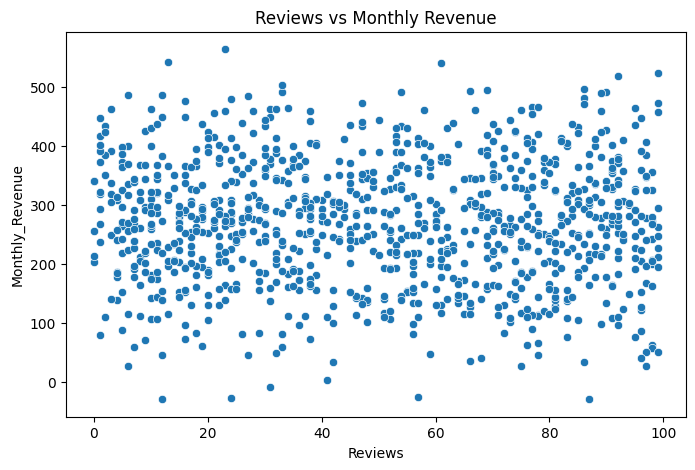

In [20]:
# EXPLANATION: Scatter plot for reviews vs monthly revenue.
# Input: 'Reviews' and 'Monthly_Revenue'.
# Output: Scatter plot.
# Interpretation: Shows if a higher volume of reviews correlates with more revenue.
plt.figure(figsize=(8,5))
sns.scatterplot(x='Reviews', y='Monthly_Revenue', data=dataset)
plt.title('Reviews vs Monthly Revenue')
plt.show()

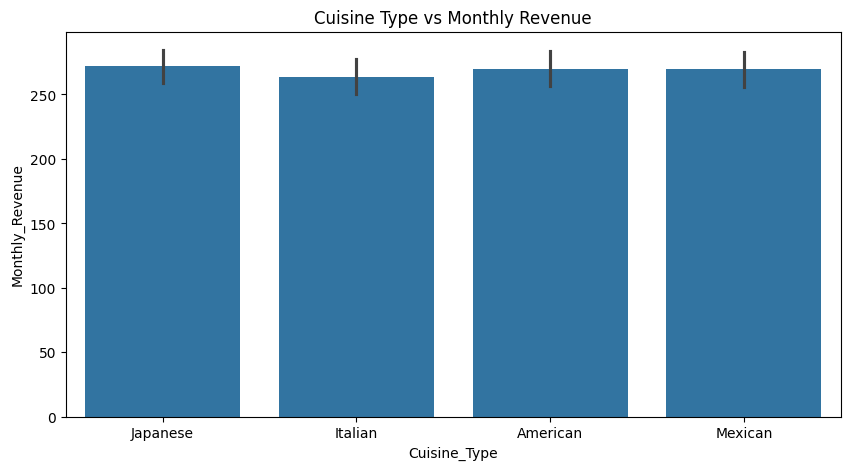

In [22]:
# EXPLANATION: Bar plot comparing average revenue across cuisine types.
# Input: 'Cuisine_Type' and 'Monthly_Revenue'.
# Output: Bar chart.
# Interpretation: Determines which type of cuisine tends to make the most money.
plt.figure(figsize=(10,5))
sns.barplot(x='Cuisine_Type', y='Monthly_Revenue', data=dataset)
plt.title('Cuisine Type vs Monthly Revenue')
plt.show()

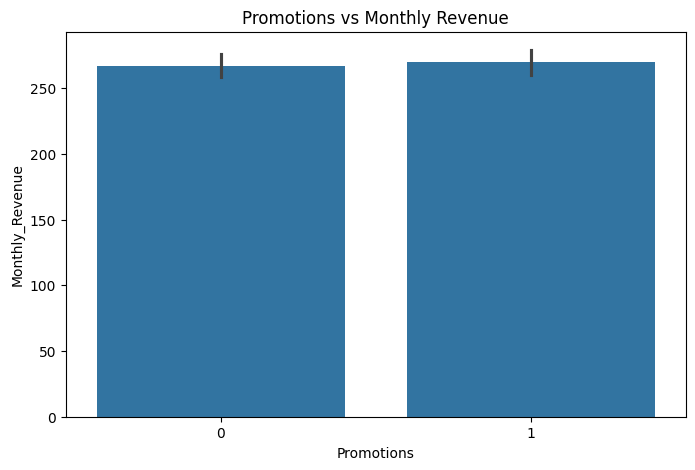

In [23]:
# EXPLANATION: Bar plot checking if promotions impact revenue.
# Input: 'Promotions' and 'Monthly_Revenue'.
# Output: Bar chart.
# Interpretation: Indicates whether running promotions drives higher sales.
plt.figure(figsize=(8,5))
sns.barplot(x='Promotions', y='Monthly_Revenue', data=dataset)
plt.title('Promotions vs Monthly Revenue')
plt.show()

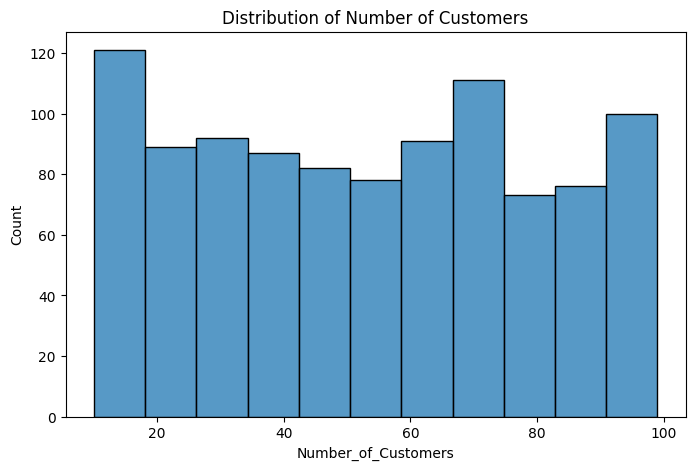

In [24]:
# EXPLANATION: Histogram of Number of Customers.
# Input: 'Number_of_Customers' column.
# Output: Histogram.
# Interpretation: Shows the distribution of customer foot traffic across all restaurants.
plt.figure(figsize=(8,5))
sns.histplot(dataset['Number_of_Customers'], kde=False)
plt.title('Distribution of Number of Customers')
plt.show()

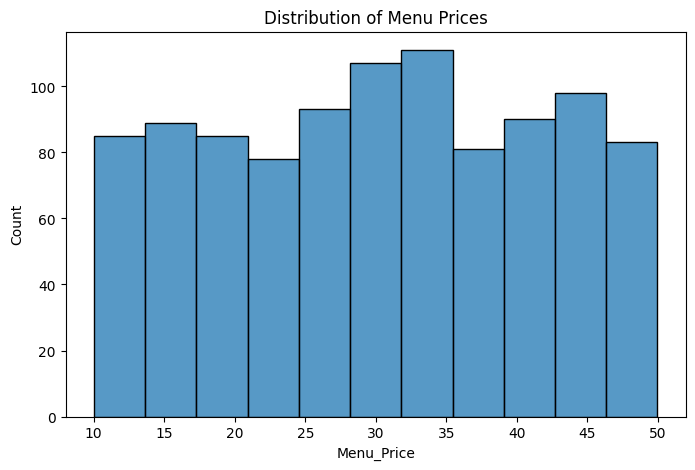

In [25]:
# EXPLANATION: Histogram of Menu Prices.
# Input: 'Menu_Price' column.
# Output: Histogram.
# Interpretation: Shows the most common price ranges for menus.
plt.figure(figsize=(8,5))
sns.histplot(dataset['Menu_Price'], kde=False)
plt.title('Distribution of Menu Prices')
plt.show()

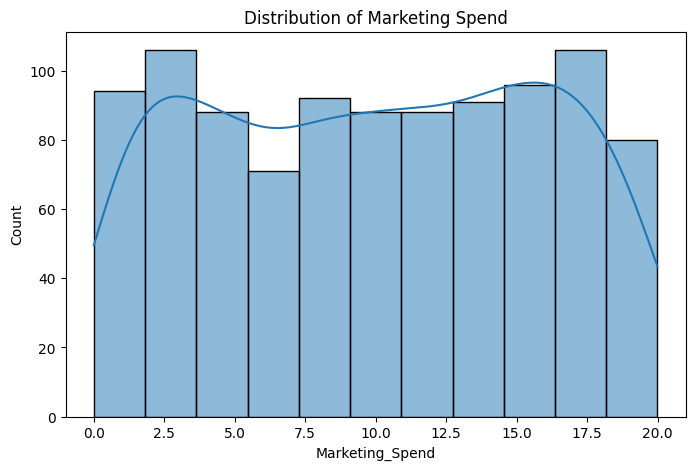

In [26]:
# EXPLANATION: Histogram of Marketing Spend.
# Input: 'Marketing_Spend' column.
# Output: Histogram.
# Interpretation: Shows the variance in how much restaurants spend on marketing.
plt.figure(figsize=(8,5))
sns.histplot(dataset['Marketing_Spend'], kde=True)
plt.title('Distribution of Marketing Spend')
plt.show()

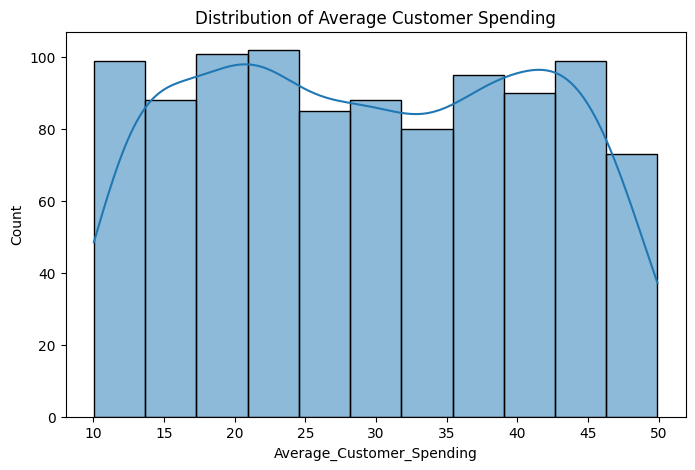

In [27]:
# EXPLANATION: Histogram of Average Customer Spending.
# Input: 'Average_Customer_Spending' column.
# Output: Histogram.
# Interpretation: Shows how much individual customers usually spend.
plt.figure(figsize=(8,5))
sns.histplot(dataset['Average_Customer_Spending'], kde=True)
plt.title('Distribution of Average Customer Spending')
plt.show()

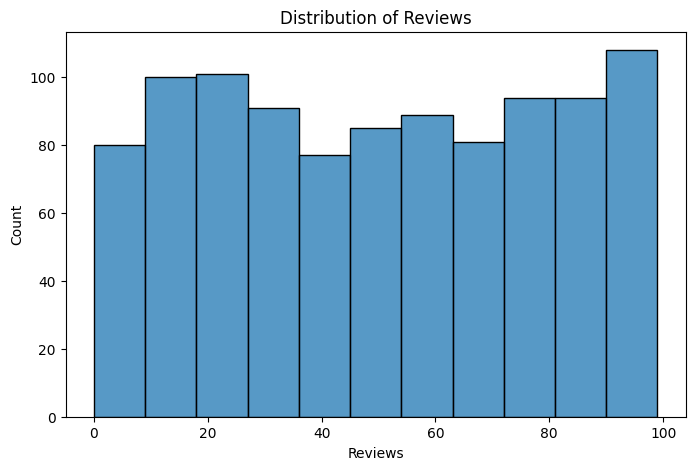

In [28]:
# EXPLANATION: Histogram of Reviews.
# Input: 'Reviews' column.
# Output: Histogram.
# Interpretation: Visualizes how frequently restaurants get reviewed.
plt.figure(figsize=(8,5))
sns.histplot(dataset['Reviews'], kde=False)
plt.title('Distribution of Reviews')
plt.show()

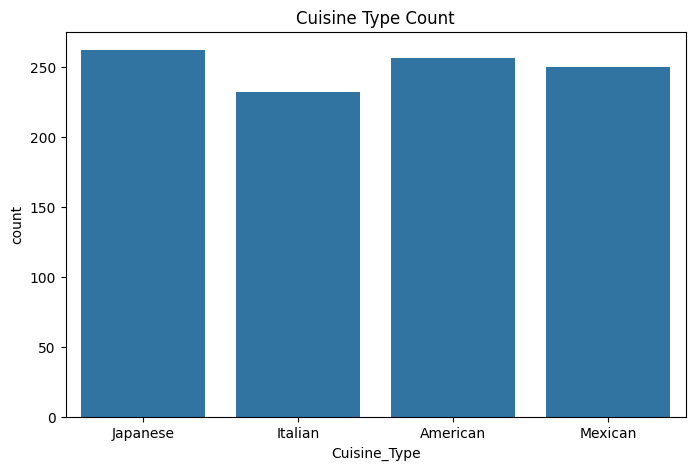

In [29]:
# EXPLANATION: Countplot showing frequency distribution of cuisine types.
# Input: 'Cuisine_Type' column.
# Output: Countplot chart.
# Interpretation: Checks if the dataset is balanced across different cuisines.
plt.figure(figsize=(8,5))
sns.countplot(x='Cuisine_Type', data=dataset)
plt.title('Cuisine Type Count')
plt.show()

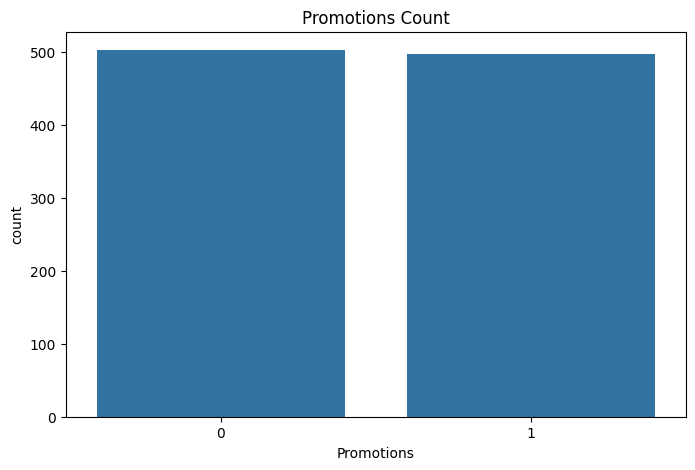

In [30]:
# EXPLANATION: Countplot for the 'Promotions' variable.
# Input: 'Promotions' column.
# Output: Countplot chart.
# Interpretation: Displays how many restaurants run promotions vs those that don't.
plt.figure(figsize=(8,5))
sns.countplot(x='Promotions', data=dataset)
plt.title('Promotions Count')
plt.show()

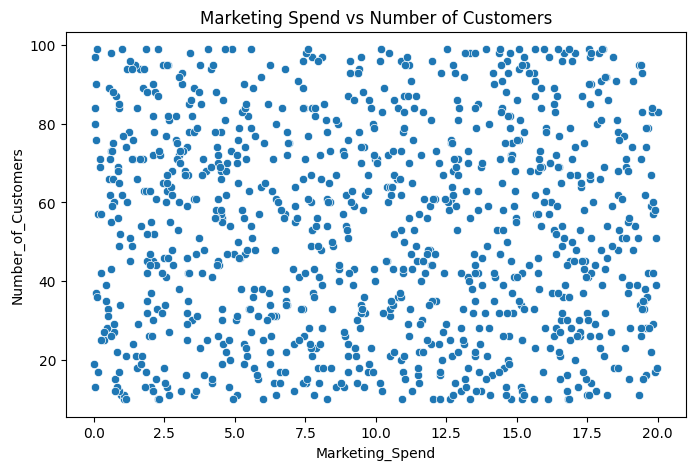

In [31]:
# EXPLANATION: Scatter plot looking for trends between Marketing Spend and Customers.
# Input: 'Marketing_Spend' and 'Number_of_Customers'.
# Output: Scatter plot.
# Interpretation: Evaluates if spending more on marketing brings in more customers.
plt.figure(figsize=(8,5))
sns.scatterplot(x='Marketing_Spend', y='Number_of_Customers', data=dataset)
plt.title('Marketing Spend vs Number of Customers')
plt.show()

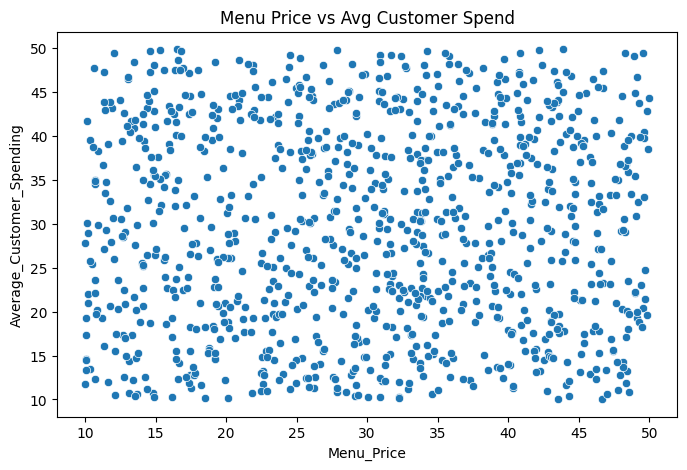

In [32]:
# EXPLANATION: Scatter plot for Menu Price vs Average Customer Spending.
# Input: 'Menu_Price' and 'Average_Customer_Spending'.
# Output: Scatter plot chart.
# Interpretation: Checks if higher menu prices dictate higher final bills per customer.
plt.figure(figsize=(8,5))
sns.scatterplot(x='Menu_Price', y='Average_Customer_Spending', data=dataset)
plt.title('Menu Price vs Avg Customer Spend')
plt.show()

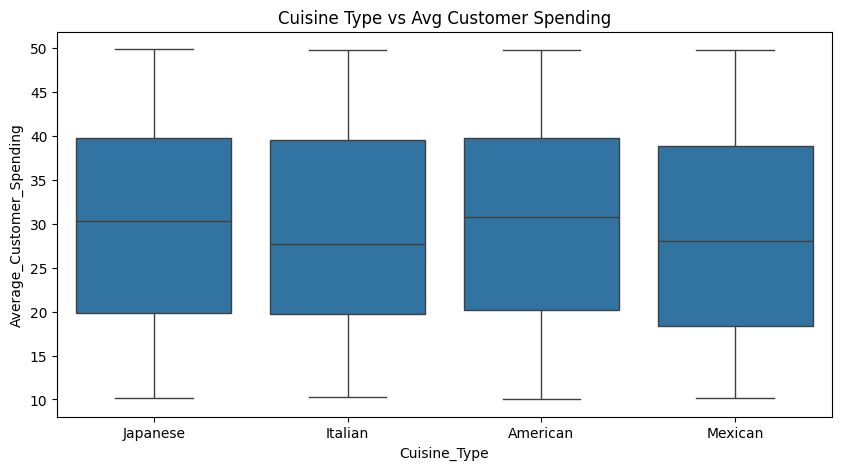

In [33]:
# EXPLANATION: Boxplot examining average spending by cuisine type.
# Input: 'Cuisine_Type' and 'Average_Customer_Spending'.
# Output: Boxplot.
# Interpretation: Visualizes the spending range for each cuisine.
plt.figure(figsize=(10,5))
sns.boxplot(x='Cuisine_Type', y='Average_Customer_Spending', data=dataset)
plt.title('Cuisine Type vs Avg Customer Spending')
plt.show()

In [34]:
# EXPLANATION: Calculates numerical count of each cuisine type.
# Input: 'Cuisine_Type' column.
# Output: Pandas Series showing counts.
# Interpretation: Validates the countplot numerically.
dataset['Cuisine_Type'].value_counts()

Cuisine_Type
Japanese    262
American    256
Mexican     250
Italian     232
Name: count, dtype: int64

In [35]:
# EXPLANATION: Calculates numerical count of promotions status.
# Input: 'Promotions' column.
# Output: Pandas Series showing counts.
# Interpretation: Provides precise class balance for marketing promos.
dataset['Promotions'].value_counts()

Promotions
0    503
1    497
Name: count, dtype: int64

In [36]:
# EXPLANATION: Binned value counts for number of customers.
# Input: 'Number_of_Customers' column.
# Output: Pandas Series.
# Interpretation: Groups foot traffic into 5 brackets for easier analysis.
dataset['Number_of_Customers'].value_counts(bins=5)

(9.91, 27.8]    219
(27.8, 45.6]    206
(63.4, 81.2]    204
(45.6, 63.4]    187
(81.2, 99.0]    184
Name: count, dtype: int64

In [37]:
# EXPLANATION: Binned value counts for reviews.
# Input: 'Reviews' column.
# Output: Pandas Series.
# Interpretation: Groups review counts into 5 bins to understand popularity ranges.
dataset['Reviews'].value_counts(bins=5)

(19.8, 39.6]    211
(79.2, 99.0]    211
(-0.1, 19.8]    204
(59.4, 79.2]    195
(39.6, 59.4]    179
Name: count, dtype: int64

In [38]:
# EXPLANATION: Binned value counts for monthly revenue.
# Input: 'Monthly_Revenue' column.
# Output: Pandas Series.
# Interpretation: Groups target values into ranges.
dataset['Monthly_Revenue'].value_counts(bins=5)

(207.966, 326.438]    428
(326.438, 444.91]     247
(89.494, 207.966]     237
(444.91, 563.381]      45
(-29.571, 89.494]      43
Name: count, dtype: int64

In [39]:
# EXPLANATION: Binned value counts for menu prices.
# Input: 'Menu_Price' column.
# Output: Pandas Series.
# Interpretation: Shows price bracket frequencies.
dataset['Menu_Price'].value_counts(bins=5)

(25.995, 33.988]               230
(33.988, 41.981]               200
(41.981, 49.974]               194
(9.969000000000001, 18.002]    192
(18.002, 25.995]               184
Name: count, dtype: int64

In [40]:
# EXPLANATION: Binned value counts for marketing spend.
# Input: 'Marketing_Spend' column.
# Output: Pandas Series.
# Interpretation: Shows how spending levels are distributed.
dataset['Marketing_Spend'].value_counts(bins=5)

(-0.0172, 4.002]    213
(15.996, 19.994]    202
(11.998, 15.996]    201
(8.0, 11.998]       194
(4.002, 8.0]        190
Name: count, dtype: int64

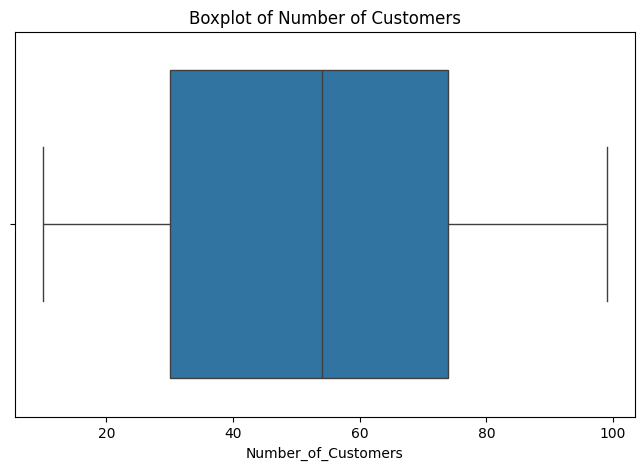

In [41]:
# EXPLANATION: Creates a boxplot for Number of Customers.
# Input: 'Number_of_Customers' column.
# Output: Boxplot chart.
# Interpretation: Spots outlier days/months with extreme foot traffic.
plt.figure(figsize=(8,5))
sns.boxplot(x='Number_of_Customers', data=dataset)
plt.title('Boxplot of Number of Customers')
plt.show()

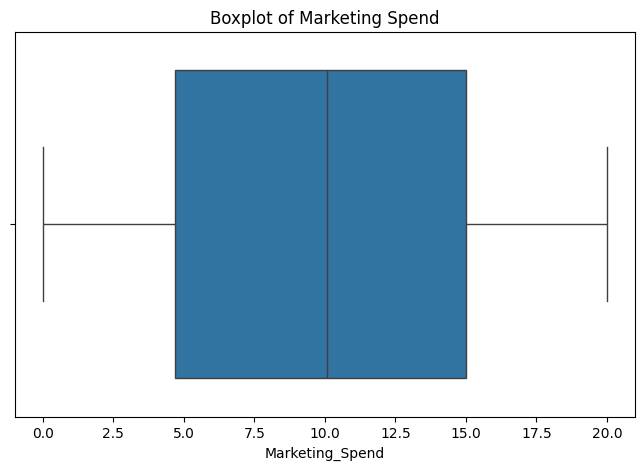

In [42]:
# EXPLANATION: Creates a boxplot for Marketing Spend.
# Input: 'Marketing_Spend' column.
# Output: Boxplot chart.
# Interpretation: Identifies extreme advertising budgets.
plt.figure(figsize=(8,5))
sns.boxplot(x='Marketing_Spend', data=dataset)
plt.title('Boxplot of Marketing Spend')
plt.show()

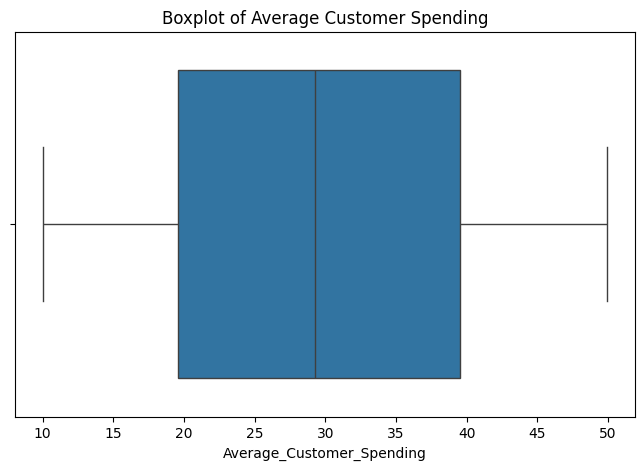

In [43]:
# EXPLANATION: Creates a boxplot for Average Customer Spending.
# Input: 'Average_Customer_Spending' column.
# Output: Boxplot chart.
# Interpretation: Identifies unrealistic or unusually high per-person bills.
plt.figure(figsize=(8,5))
sns.boxplot(x='Average_Customer_Spending', data=dataset)
plt.title('Boxplot of Average Customer Spending')
plt.show()

In [44]:
# EXPLANATION: Extracts numeric columns for correlation analysis.
# Input: The 'dataset' DataFrame.
# Output: List of numeric column names.
# Interpretation: Prepares variables for mathematical correlation.
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['Number_of_Customers', 'Menu_Price', 'Marketing_Spend',
       'Average_Customer_Spending', 'Promotions', 'Reviews',
       'Monthly_Revenue'],
      dtype='str')

In [45]:
# EXPLANATION: Calculates Pearson correlation coefficients.
# Input: Numeric columns.
# Output: Correlation matrix dataframe.
# Interpretation: Identifies linear relationships between numerical features.
corr_matrix = dataset[numeric_cols].corr()
corr_matrix

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
Number_of_Customers,1.000000,0.033470,-0.007024,-0.013898,0.058693,-0.010140,0.745239
Menu_Price,0.033470,1.000000,0.016319,0.020808,0.022068,0.003792,0.259579
Marketing_Spend,-0.007024,0.016319,1.000000,-0.058586,-0.041838,-0.031470,0.269929
Average_Customer_Spending,-0.013898,0.020808,-0.058586,1.000000,0.006620,0.054163,-0.035665
Promotions,0.058693,0.022068,-0.041838,0.006620,1.000000,-0.021635,0.014869
Reviews,-0.010140,0.003792,-0.031470,0.054163,-0.021635,1.000000,-0.024946
Monthly_Revenue,0.745239,0.259579,0.269929,-0.035665,0.014869,-0.024946,1.000000


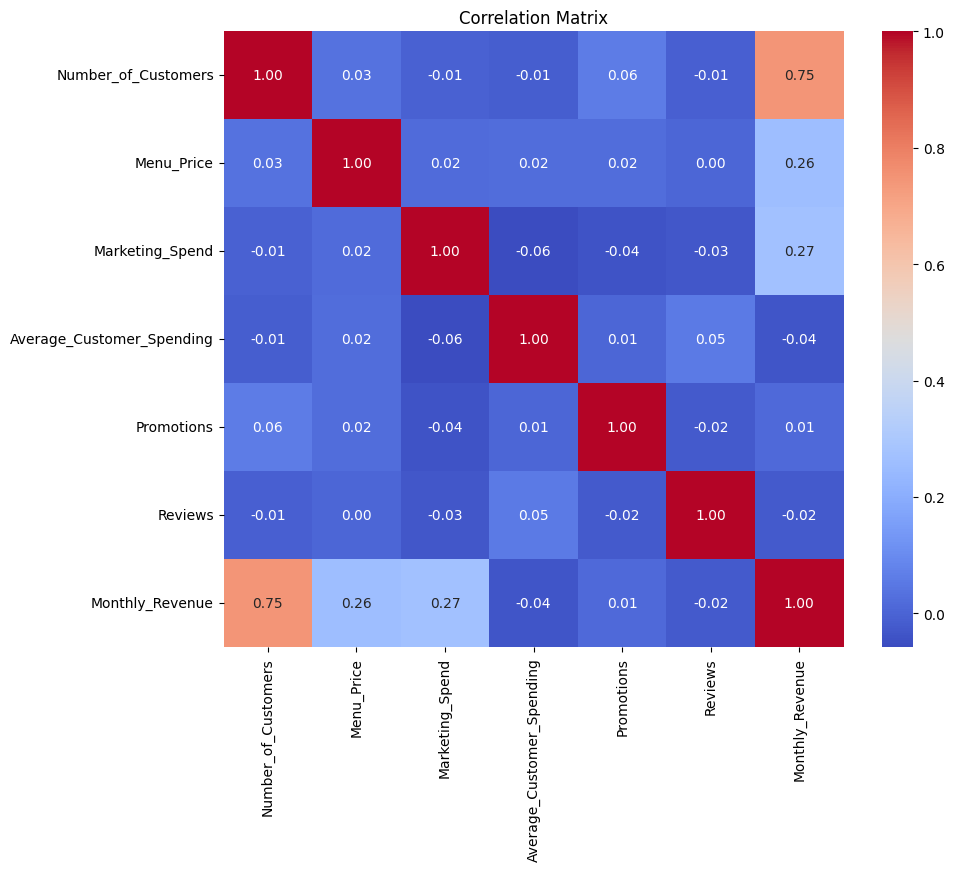

In [46]:
# EXPLANATION: Generates Heatmap of the correlation matrix.
# Input: 'corr_matrix'.
# Output: Seaborn heatmap.
# Interpretation: Visual tool to spot multicollinearity and feature strength against revenue.
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [47]:
# EXPLANATION: Groups data by Cuisine Type and computes mean revenue.
# Input: 'Cuisine_Type' and 'Monthly_Revenue'.
# Output: Pandas Series showing mean values.
# Interpretation: Provides exact statistical average per group.
dataset.groupby('Cuisine_Type')['Monthly_Revenue'].mean()

Cuisine_Type
American    269.604825
Italian     263.699862
Japanese    271.700186
Mexican     269.366082
Name: Monthly_Revenue, dtype: float64

In [48]:
# EXPLANATION: Groups data by Promotions and computes mean revenue.
# Input: 'Promotions' and 'Monthly_Revenue'.
# Output: Pandas Series showing mean values.
# Interpretation: Quantifies how much extra revenue a promotion brings in on average.
dataset.groupby('Promotions')['Monthly_Revenue'].mean()

Promotions
0    267.188084
1    270.278805
Name: Monthly_Revenue, dtype: float64

In [49]:
# EXPLANATION: Applies One-Hot Encoding to categorical variables like Cuisine Type.
# Input: Entire 'dataset'.
# Output: Dataset with text columns converted to binary (0/1).
# Interpretation: Crucial for linear regression; drops first to prevent multicollinearity.
dataset = pd.get_dummies(data=dataset, drop_first=True)

In [50]:
# EXPLANATION: Displays top rows of encoded dataset.
# Input: Encoded 'dataset'.
# Output: Top 5 rows.
# Interpretation: Visual verification of boolean dummy columns.
dataset.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue,Cuisine_Type_Italian,Cuisine_Type_Japanese,Cuisine_Type_Mexican
0,61,43.117635,12.663793,36.236133,0,45,350.912040,False,True,False
1,24,40.020077,4.577892,17.952562,0,36,221.319091,True,False,False
2,81,41.981485,4.652911,22.600420,1,91,326.529763,False,True,False
3,70,43.005307,4.416053,18.984098,1,59,348.190573,True,False,False
4,30,17.456199,3.475052,12.766143,1,30,185.009121,True,False,False


In [51]:
# EXPLANATION: Checks dimensions post-encoding.
# Input: Encoded 'dataset'.
# Output: Tuple (Rows, Columns).
# Interpretation: Number of columns increases due to dummy variables.
dataset.shape

(1000, 10)

In [52]:
# EXPLANATION: Separates independent variables (features) from target.
# Input: Encoded 'dataset'.
# Output: DataFrame 'X' excluding 'Monthly_Revenue'.
# Interpretation: Creates input matrix (X) for model training.
X = dataset.drop('Monthly_Revenue', axis=1)

In [53]:
# EXPLANATION: Isolates the dependent variable (target).
# Input: 'Monthly_Revenue' column.
# Output: Series 'y'.
# Interpretation: This is what the model is trying to predict.
y = dataset['Monthly_Revenue']

In [54]:
X.head()
y.head()

0    350.912040
1    221.319091
2    326.529763
3    348.190573
4    185.009121
Name: Monthly_Revenue, dtype: float64

In [55]:
# EXPLANATION: Imports train_test_split function.
# Input: None.
# Output: Function loaded into memory.
# Interpretation: Required to split data into train/test portions.
from sklearn.model_selection import train_test_split

In [56]:
# EXPLANATION: Splits data into 80% training and 20% testing.
# Input: X and y.
# Output: 4 subsets: x_train, x_test, y_train, y_test.
# Interpretation: Reserves 20% for validation. Random state ensures reproducibility.
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [57]:
x_train
x_test
y_train
y_test


993    139.180237
859    429.953592
298    288.532225
553    256.692083
672    423.692203
          ...    
679    319.672243
722     72.068505
215    215.068530
653    131.822709
150    151.864732
Name: Monthly_Revenue, Length: 200, dtype: float64

In [58]:
# EXPLANATION: Imports StandardScaler for feature scaling.
# Input: None.
# Output: Tool loaded.
# Interpretation: Needed to standardize distributions for regression.
from sklearn.preprocessing import StandardScaler

In [59]:
# EXPLANATION: Initializes StandardScaler object.
# Input: None.
# Output: Scaling object 'sc'.
# Interpretation: Prepares standardizer.
sc = StandardScaler()

In [60]:
# EXPLANATION: Fits scaler to training data and transforms it.
# Input: 'x_train'.
# Output: Standardized 'x_train'.
# Interpretation: Learns mean/std from training data and scales.
x_train = sc.fit_transform(x_train)

In [61]:
# EXPLANATION: Applies existing scaler to test data.
# Input: 'x_test'.
# Output: Standardized 'x_test'.
# Interpretation: Uses only transform() to prevent data leakage.
x_test = sc.transform(x_test)

In [62]:
# EXPLANATION: Imports LinearRegression algorithm.
# Input: None.
# Output: Model class loaded.
# Interpretation: Essential package for predicting continuous variables.
from sklearn.linear_model import LinearRegression

In [63]:
# EXPLANATION: Initializes and trains the linear regression model.
# Input: 'x_train' and 'y_train'.
# Output: Trained regressor object.
# Interpretation: Calculates optimal weights for predicting revenue.
regressor_mlr = LinearRegression()
regressor_mlr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
# EXPLANATION: Uses trained model to predict on test data.
# Input: 'x_test'.
# Output: Predicted values 'y_pred'.
# Interpretation: Predictions to be compared against actuals.
y_pred = regressor_mlr.predict(x_test)

In [65]:
# EXPLANATION: Imports R-squared scoring metric.
# Input: None.
# Output: Metric function loaded.
# Interpretation: Defines how much variance is explained by features.
from sklearn.metrics import r2_score

In [66]:
# EXPLANATION: Calculates the final R-squared (R2) score.
# Input: 'y_test' and 'y_pred'.
# Output: Float accuracy score.
# Interpretation: Closer to 1.0 indicates a highly accurate regression model.
r2_score(y_test, y_pred)

0.6898240430197424